In [ ]:
# Import necessary libraries
!pip install av # install PyAV
!pip install retina-face

import os
import av
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from timm import create_model
from retinaface import RetinaFace
from PIL import Image

a = 1  # Counter for processed videos

# Define paths
input_folder = "/content/drive/MyDrive/deepfake Dataset/PART1"
output_folder = "/content/drive/MyDrive/deepfake Dataset/proced"
os.makedirs(output_folder, exist_ok=True)

# Load RetinaFace model (GPU-accelerated)
face_detector = RetinaFace.build_model()

# Load EfficientNet-B4 for feature extraction
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = create_model('efficientnet_b4', pretrained=True)
feature_extractor = nn.Sequential(*list(feature_extractor.children())[:-2])  # Remove classification layers
feature_extractor = feature_extractor.to(device).eval()

# Define transformation pipeline
transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def detect_and_crop_face(image):
    """Detects and crops the largest face using RetinaFace."""
    faces = RetinaFace.detect_faces(image, model=face_detector)

    if isinstance(faces, dict) and faces:
        largest_face = None
        max_area = 0

        for key in faces.keys():
            identity = faces[key]
            x1, y1, x2, y2 = identity["facial_area"]
            face_area = (x2 - x1) * (y2 - y1)

            if face_area > max_area:
                max_area = face_area
                largest_face = image[y1:y2, x1:x2]

        if largest_face is not None and largest_face.size > 0:
            return cv2.resize(largest_face, (384, 384))

    return None

def get_frame_count_by_duration(duration_seconds):
    """Returns the number of frames to sample based on video duration."""
    if duration_seconds <= 10:
        return 30
    elif duration_seconds <= 30:
        return 60
    elif duration_seconds <= 60:
        return 100
    elif duration_seconds <= 120:
        return 150
    elif duration_seconds <= 300:
        return 200
    elif duration_seconds <= 600:
        return 250
    else:
        return 300  # max cap

def sample_frame_indices(total_frames, duration_seconds):
    """Samples evenly spaced frame indices based on video duration."""
    num_samples = get_frame_count_by_duration(duration_seconds)

    if total_frames >= num_samples:
        indices = np.linspace(0, total_frames - 1, num_samples, dtype=int)
    else:
        indices = list(range(total_frames))
        while len(indices) < num_samples:
            indices.append(indices[-1])  # repeat last frame
    return indices

def extract_frames_and_features(video_path):
    """Extracts frames, crops faces, and computes feature vectors."""
    try:
        container = av.open(video_path, options={'hwaccel': 'cuda'})  # GPU-accelerated decoding
        video_stream = container.streams.video[0]
        total_frames = video_stream.frames
        fps = video_stream.average_rate  # Frames per second of video
        duration_seconds = total_frames / fps  # Duration of the video in seconds
        frame_indices = sample_frame_indices(total_frames, duration_seconds)

        feature_vectors = []

        for i, frame in enumerate(container.decode(video=0)):
            if i in frame_indices:
                img = frame.to_ndarray(format="bgr24")  # Convert frame to OpenCV format
                cropped_face = detect_and_crop_face(img)

                if cropped_face is not None:
                    img = Image.fromarray(cv2.cvtColor(cropped_face, cv2.COLOR_BGR2RGB))
                    img = transform(img).unsqueeze(0).to(device)

                    with torch.no_grad():
                        features = feature_extractor(img)
                        features = torch.mean(features, dim=[2, 3])  # Global Average Pooling
                        feature_vectors.append(features.cpu().numpy()[0])

        # Convert feature_vectors to numpy array to handle its shape correctly
        feature_vectors = np.array(feature_vectors)

        # Ensure we have the target number of frames (e.g., 60) using interpolation/padding
        num_frames = feature_vectors.shape[0] if feature_vectors.size > 0 else 0
        target_frames = get_frame_count_by_duration(duration_seconds)

        if num_frames > target_frames:
            indices = np.linspace(0, num_frames - 1, target_frames, dtype=int)
            feature_vectors = feature_vectors[indices]
        elif num_frames < target_frames:
            pad_size = target_frames - num_frames
            pad_array = np.zeros((pad_size, 1792))
            feature_vectors = np.vstack((feature_vectors, pad_array))

        return feature_vectors

    except Exception as e:
        print(f"❌ Error processing {video_path}: {e}")
        return None


def process_videos(input_folder, output_folder):
    """Processes videos by extracting features directly."""
    for category in ["real", "fake"]:
        category_path = os.path.join(input_folder, category)
        output_category_path = os.path.join(output_folder, category)
        os.makedirs(output_category_path, exist_ok=True)

        for video_name in os.listdir(category_path):
            video_path = os.path.join(category_path, video_name)
            if not video_name.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
                continue

            output_file = os.path.join(output_category_path, f"{os.path.splitext(video_name)[0]}.npy")
            if os.path.exists(output_file):
                print(f"⚡ Skipping {video_name}, already processed.")
                continue

            features = extract_frames_and_features(video_path)
            global a
            if features is not None:
                np.save(output_file, features)
                print(f"{a}✅ Processed {video_name}, Shape: {features.shape}")
                a += 1

# Run the optimized pipeline
process_videos(input_folder, output_folder)

print("🚀 Feature extraction completed on GPU! ✅")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 56.7 MB/s eta 0:00:00
25-04-17 16:24:36 - Directory /root/.deepface created
25-04-17 16:24:36 - Directory /root/.deepface/weights created
25-04-17 16:24:36 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5
100%|██████████| 119M/119M [00:00<00:00, 131MB/s]


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

⚡ Skipping Copy of 01__outside_talking_still_laughing.mp4, already processed.
⚡ Skipping Copy of 01__walk_down_hall_angry.mp4, already processed.
⚡ Skipping Copy of 03__exit_phone_room.mp4, already processed.
⚡ Skipping Copy of 01__kitchen_still.mp4, already processed.
⚡ Skipping Copy of 01__meeting_serious.mp4, already processed.
⚡ Skipping Copy of 02__exit_phone_room.mp4, already processed.
⚡ Skipping Copy of 03__kitchen_still.mp4, already processed.
⚡ Skipping Copy of 01__walking_outside_cafe_disgusted.mp4, already processed.
⚡ Skipping Copy of 02__outside_talking_still_laughing.mp4, already processed.
⚡ Skipping Copy of 02__podium_speech_happy.mp4, already processed.
⚡ Skipping Copy of 04__kitchen_still.mp4, already processed.
⚡ Skipping Copy of 04__walk_down_hall_angry.mp4, already processed.
⚡ Skipping Copy of 03__walk_down_hall_angry.mp4, already processed.
⚡ Skipping Copy of 03__secret_conversation.mp4, already processed.
⚡ Skipping Copy of 04__talking_against_wall.mp4, already

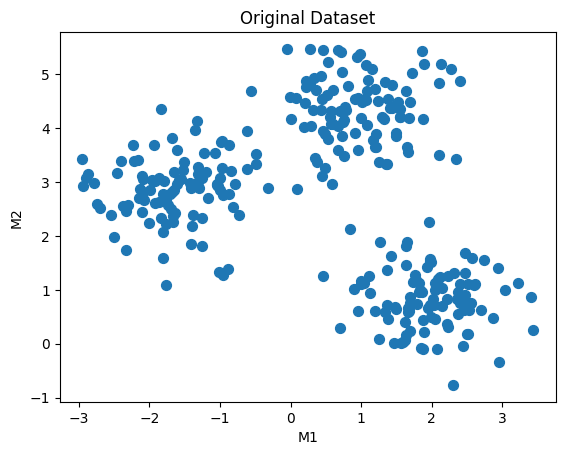

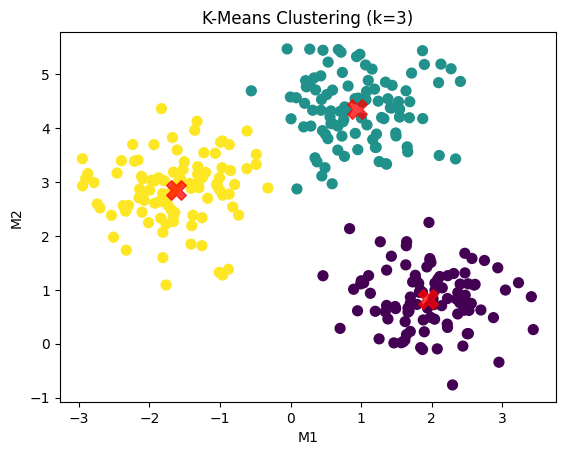

In [ ]:
# Experiment No: 12
# Title: Implement K-Means clustering algorithm.
# Aim: Demonstrate K-Means clustering algorithm

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generate sample data
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

# Visualize the original dataset
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Original Dataset")
plt.xlabel("M1")
plt.ylabel("M2")
plt.show()

# Apply KMeans Clustering
k = 3  # Number of clusters
kmeans = KMeans(n_clusters=k)
kmeans.fit(X)

# Get predicted cluster labels
y_kmeans = kmeans.predict(X)

# Visualize the clustered data
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

# Plot the centroids
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.title("K-Means Clustering (k=3)")
plt.xlabel("M1")
plt.ylabel("M2")
plt.show()


In [ ]:
import multiprocessing
print(multiprocessing.cpu_count())


2


In [ ]:
from googletrans import Translator

translator = Translator()
text = "Hello, how are you?"
translated = translator.translate(text, dest='fr')  # Translate to French
print(translated.text)


ModuleNotFoundError: No module named 'googletrans'